# DataCred: A "Nutrition Label" for Datasets

**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship (BharatCares × AICTE)

**Author:** Amruta

---

## Problem Statement

Before a dataset is used to train a model or drive a business decision, someone
needs to sanity-check it. In practice this rarely happens in a consistent way —
a dataset can look fine on the surface while being significantly incomplete,
out of date, pulled from an unreliable source, or statistically different from
the data a model was originally built on.

This project builds a **Data Trust Score**: a single 0–100 score, backed by
four transparent sub-checks, that an analyst can compute in seconds before
trusting a dataset. The idea mirrors a nutrition label — a fast, standardized
way to check something before you consume it.

## The four checks

| Check | What it measures | Method |
|---|---|---|
| **Completeness** | How much of the dataset is actually populated | % non-null cells, per column |
| **Freshness** | How current the data is | Age of newest record vs. a decay curve |
| **Source reliability** | How much the data's origin is trusted | Configurable lookup table |
| **Drift** | Whether the data's statistical distribution has shifted | Two-sample Kolmogorov–Smirnov test vs. a historical baseline |

The four scores are combined into one weighted overall score.


## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from datetime import datetime, timedelta
from dataclasses import dataclass, field
from typing import Optional
import json
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4)


## 2. Dataset

**Dataset used:** Synthetically generated retail sales data (created below), designed
to mimic a realistic e-commerce orders table. Synthetic data was used so the
project could deliberately demonstrate *known* data-quality problems — missing
values, stale timestamps, and distribution drift — and show the trust score
correctly catching each one. The same code works unchanged on any real CSV or
database table; swap the generated DataFrames below for `pd.read_csv("your_file.csv")`.

Two datasets are generated:
- **`baseline_df`** — a "known good" historical snapshot (e.g. last quarter's clean export)
- **`current_df`** — a newer dataset with deliberately injected issues, to be scored against the baseline


In [2]:
def make_baseline(n=2000):
    base_date = datetime(2025, 6, 1)
    df = pd.DataFrame({
        "order_id": range(1, n + 1),
        "customer_age": np.random.normal(loc=38, scale=12, size=n).clip(18, 90).round(0),
        "order_value": np.random.gamma(shape=2.0, scale=45, size=n).round(2),
        "items_in_order": np.random.poisson(lam=3, size=n) + 1,
        "region": np.random.choice(["North", "South", "East", "West"], size=n, p=[0.3, 0.25, 0.25, 0.2]),
        "last_updated": [base_date - timedelta(days=int(x)) for x in np.random.randint(0, 5, size=n)],
    })
    return df


def make_current(n=1800):
    # Shifted ~90 days later than the baseline, and stale relative to "today"
    # -- the freshness check should flag this.
    base_date = datetime(2025, 6, 1) + timedelta(days=90)

    df = pd.DataFrame({
        "order_id": range(2001, 2001 + n),
        # Drift injected: mean age shifted up meaningfully (38 -> 47)
        "customer_age": np.random.normal(loc=47, scale=14, size=n).clip(18, 95).round(0),
        # Drift injected: order value distribution shifted and more skewed
        "order_value": np.random.gamma(shape=1.3, scale=70, size=n).round(2),
        "items_in_order": np.random.poisson(lam=3, size=n) + 1,
        "region": np.random.choice(["North", "South", "East", "West"], size=n, p=[0.3, 0.25, 0.25, 0.2]),
        "last_updated": [base_date - timedelta(days=int(x)) for x in np.random.randint(0, 5, size=n)],
    })

    # Inject missing values so the completeness check has something to catch
    for col, frac in [("customer_age", 0.12), ("region", 0.05), ("order_value", 0.02)]:
        mask = np.random.rand(n) < frac
        df.loc[mask, col] = np.nan

    return df


baseline_df = make_baseline()
current_df = make_current()

print(f"baseline_df: {baseline_df.shape}")
print(f"current_df:  {current_df.shape}")
current_df.head(10)


baseline_df: (2000, 6)
current_df:  (1800, 6)


,order_id,customer_age,order_value,items_in_order,region,last_updated
0,2001,59.0,20.98,6,East,2025-08-28
1,2002,51.0,8.69,7,East,2025-08-26
2,2003,43.0,43.23,2,North,2025-08-29
3,2004,41.0,55.57,5,South,2025-08-29
4,2005,NaN,33.59,4,NaN,2025-08-28
5,2006,36.0,50.65,4,NaN,2025-08-30
6,2007,43.0,144.35,2,NaN,2025-08-29
7,2008,41.0,73.71,5,North,2025-08-28
8,2009,59.0,54.70,5,North,2025-08-30
9,2010,21.0,123.06,5,North,2025-08-30


## 3. Exploratory Data Analysis

In [3]:
current_df.describe(include="all")


,order_id,customer_age,order_value,items_in_order,region,last_updated
count,1800.00000,1576.000000,1766.000000,1800.000000,1715,1800
unique,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,NaN,North,NaN
freq,NaN,NaN,NaN,NaN,537,NaN
mean,2900.50000,46.973985,89.043579,4.017778,NaN,2025-08-28 00:04:48
min,2001.00000,18.000000,0.060000,1.000000,NaN,2025-08-26 00:00:00
25%,2450.75000,37.000000,33.592500,3.000000,NaN,2025-08-27 00:00:00
50%,2900.50000,47.000000,68.540000,4.000000,NaN,2025-08-28 00:00:00
75%,3350.25000,56.000000,120.665000,5.000000,NaN,2025-08-29 00:00:00
max,3800.00000,92.000000,942.770000,11.000000,NaN,2025-08-30 00:00:00


In [4]:
print("Missing values per column (current_df):")
print((current_df.isnull().mean() * 100).round(2).astype(str) + " %")


Missing values per column (current_df):
order_id            0.0 %
customer_age      12.44 %
order_value        1.89 %
items_in_order      0.0 %
region             4.72 %
last_updated        0.0 %
dtype: str


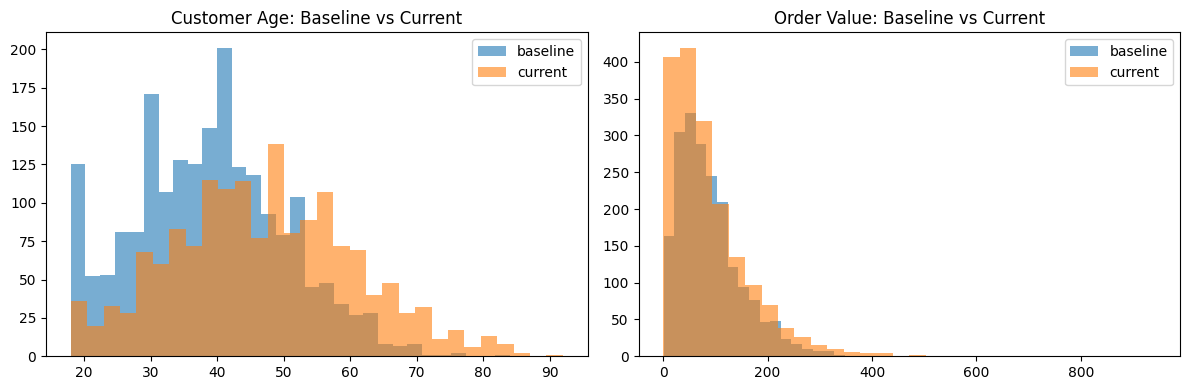

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(baseline_df["customer_age"].dropna(), bins=30, alpha=0.6, label="baseline")
axes[0].hist(current_df["customer_age"].dropna(), bins=30, alpha=0.6, label="current")
axes[0].set_title("Customer Age: Baseline vs Current")
axes[0].legend()

axes[1].hist(baseline_df["order_value"].dropna(), bins=30, alpha=0.6, label="baseline")
axes[1].hist(current_df["order_value"].dropna(), bins=30, alpha=0.6, label="current")
axes[1].set_title("Order Value: Baseline vs Current")
axes[1].legend()

plt.tight_layout()
plt.show()


The two histograms already hint at what the drift check will confirm
numerically: `customer_age` has shifted noticeably higher, and `order_value`
has a visibly different (more skewed) shape in the current data compared to
the baseline.


## 4. Configuration

Central place for the two things a real organization would customize: how
much each check contributes to the final score, and how much each data
source is trusted.


In [6]:
DEFAULT_WEIGHTS = {
    "completeness": 0.30,
    "freshness": 0.20,
    "source_reliability": 0.20,
    "drift": 0.30,
}

SOURCE_TRUST_TABLE = {
    "production_database": 95,
    "data_warehouse": 90,
    "verified_api": 85,
    "internal_etl_pipeline": 80,
    "partner_feed": 65,
    "manual_upload": 50,
    "third_party_export": 45,
    "unknown": 30,
}

FRESH_GRACE_DAYS = 7   # fully fresh up to this age
FRESH_MAX_DAYS = 90    # score hits 0 at this age

SCORE_BANDS = [
    (85, "High trust"),
    (65, "Moderate trust -- review before use"),
    (40, "Low trust -- investigate before use"),
    (0,  "Do not trust -- likely unsafe for modeling"),
]

def label_for_score(score: float) -> str:
    for threshold, label in SCORE_BANDS:
        if score >= threshold:
            return label
    return SCORE_BANDS[-1][1]


## 5. Check 1 — Completeness

In [7]:
@dataclass
class CompletenessResult:
    score: float
    overall_fill_rate: float
    per_column_fill_rate: dict = field(default_factory=dict)
    worst_columns: list = field(default_factory=list)

def check_completeness(df: pd.DataFrame, worst_n: int = 5) -> CompletenessResult:
    if df.empty:
        return CompletenessResult(score=0.0, overall_fill_rate=0.0)

    per_col = (1 - df.isnull().mean()).to_dict()
    overall = 1 - df.isnull().mean().mean()
    worst = sorted(per_col.items(), key=lambda kv: kv[1])[:worst_n]

    return CompletenessResult(
        score=round(overall * 100, 2),
        overall_fill_rate=round(float(overall), 4),
        per_column_fill_rate={k: round(float(v), 4) for k, v in per_col.items()},
        worst_columns=[(k, round(float(v), 4)) for k, v in worst],
    )

completeness_result = check_completeness(current_df)
completeness_result


CompletenessResult(score=np.float64(96.82), overall_fill_rate=0.9682, per_column_fill_rate={'order_id': 1.0, 'customer_age': 0.8756, 'order_value': 0.9811, 'items_in_order': 1.0, 'region': 0.9528, 'last_updated': 1.0}, worst_columns=[('customer_age', 0.8756), ('region', 0.9528), ('order_value', 0.9811), ('order_id', 1.0), ('items_in_order', 1.0)])

## 6. Check 2 — Freshness

In [8]:
@dataclass
class FreshnessResult:
    score: float
    age_days: Optional[float]
    newest_timestamp: Optional[str]
    timestamp_column: Optional[str]
    note: str = ""

def check_freshness(df, timestamp_col=None, as_of=None) -> FreshnessResult:
    as_of = as_of or datetime.utcnow()

    if timestamp_col is None or timestamp_col not in df.columns:
        return FreshnessResult(50.0, None, None, None,
                                "No timestamp column provided; defaulted to neutral score of 50.")

    ts = pd.to_datetime(df[timestamp_col], errors="coerce").dropna()
    if ts.empty:
        return FreshnessResult(0.0, None, None, timestamp_col, f"Column '{timestamp_col}' had no parseable dates.")

    newest = ts.max()
    age_days = max((as_of - newest.to_pydatetime()).total_seconds() / 86400.0, 0.0)

    if age_days <= FRESH_GRACE_DAYS:
        score = 100.0
    elif age_days >= FRESH_MAX_DAYS:
        score = 0.0
    else:
        span = FRESH_MAX_DAYS - FRESH_GRACE_DAYS
        score = 100.0 * (1 - (age_days - FRESH_GRACE_DAYS) / span)

    return FreshnessResult(round(score, 2), round(age_days, 2), str(newest), timestamp_col)

freshness_result = check_freshness(current_df, timestamp_col="last_updated")
freshness_result


/tmp/ipykernel_94/1856186726.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  as_of = as_of or datetime.utcnow()


FreshnessResult(score=0.0, age_days=385.38, newest_timestamp='2025-08-30 00:00:00', timestamp_column='last_updated', note='')

## 7. Check 3 — Source Reliability

In [9]:
@dataclass
class SourceReliabilityResult:
    score: float
    source: str
    known_source: bool

def check_source_reliability(source: str) -> SourceReliabilityResult:
    key = (source or "unknown").strip().lower().replace(" ", "_")
    known = key in SOURCE_TRUST_TABLE
    score = SOURCE_TRUST_TABLE.get(key, SOURCE_TRUST_TABLE["unknown"])
    return SourceReliabilityResult(float(score), key, known)

source_result = check_source_reliability("production_database")
source_result


SourceReliabilityResult(score=95.0, source='production_database', known_source=True)

## 8. Check 4 — Drift (vs. Baseline)

In [10]:
@dataclass
class ColumnDrift:
    column: str
    baseline_mean: float
    current_mean: float
    pct_mean_change: float
    ks_pvalue: float
    drifted: bool

@dataclass
class DriftResult:
    score: float
    columns_checked: int
    columns_drifted: int
    details: list = field(default_factory=list)
    note: str = ""

def check_drift(current_df, baseline_df, significance=0.01) -> DriftResult:
    if baseline_df is None or baseline_df.empty:
        return DriftResult(50.0, 0, 0, note="No baseline provided; defaulted to neutral score of 50.")

    numeric_cols = [c for c in current_df.columns
                    if c in baseline_df.columns
                    and pd.api.types.is_numeric_dtype(current_df[c])
                    and pd.api.types.is_numeric_dtype(baseline_df[c])]

    details = []
    for col in numeric_cols:
        cur = current_df[col].dropna().to_numpy()
        base = baseline_df[col].dropna().to_numpy()
        if len(cur) < 2 or len(base) < 2:
            continue
        ks_stat, p_value = stats.ks_2samp(cur, base)
        base_mean, cur_mean = float(np.mean(base)), float(np.mean(cur))
        pct_change = 0.0 if base_mean == 0 else round((cur_mean - base_mean) / abs(base_mean) * 100, 2)
        details.append(ColumnDrift(col, round(base_mean, 4), round(cur_mean, 4),
                                    pct_change, round(float(p_value), 5), bool(p_value < significance)))

    if not details:
        return DriftResult(50.0, 0, 0, note="No comparable numeric columns with enough data.")

    drifted_count = sum(1 for d in details if d.drifted)
    score = 100.0 * (1 - drifted_count / len(details))
    return DriftResult(round(score, 2), len(details), drifted_count, details)

drift_result = check_drift(current_df, baseline_df)
print(f"Score: {drift_result.score}  |  Columns drifted: {drift_result.columns_drifted}/{drift_result.columns_checked}")
pd.DataFrame([d.__dict__ for d in drift_result.details])


Score: 25.0  |  Columns drifted: 3/4


,column,baseline_mean,current_mean,pct_mean_change,ks_pvalue,drifted
0,order_id,1000.5000,2900.5000,189.91,0.00000,True
1,customer_age,38.7335,46.9740,21.27,0.00000,True
2,order_value,89.7049,89.0436,-0.74,0.00000,True
3,items_in_order,3.9520,4.0178,1.66,0.80103,False


## 9. Combining the Checks into One Trust Score

In [11]:
def compute_trust_score(completeness, freshness, source, drift, weights=DEFAULT_WEIGHTS):
    overall = (
        completeness.score * weights["completeness"]
        + freshness.score * weights["freshness"]
        + source.score * weights["source_reliability"]
        + drift.score * weights["drift"]
    )
    return round(overall, 2), label_for_score(overall)

overall_score, label = compute_trust_score(completeness_result, freshness_result, source_result, drift_result)
print(f"OVERALL TRUST SCORE: {overall_score} / 100  --  {label}")


OVERALL TRUST SCORE: 55.55 / 100  --  Low trust -- investigate before use


## 10. Plain-English Report

In [12]:
def explain(dataset_name, overall_score, label, completeness, freshness, source, drift):
    lines = [f"Trust Score for '{dataset_name}': {overall_score}/100 -- {label}", ""]

    if completeness.score >= 90:
        lines.append(f"- Completeness is strong ({completeness.overall_fill_rate:.0%} of cells populated).")
    elif completeness.score >= 70:
        lines.append(f"- Completeness is decent ({completeness.overall_fill_rate:.0%} filled), worth a glance.")
    else:
        lines.append(f"- Completeness is weak ({completeness.overall_fill_rate:.0%} filled) -- significant missing data.")
    if completeness.worst_columns:
        worst = ", ".join(f"{c} ({r:.0%} filled)" for c, r in completeness.worst_columns[:3])
        lines.append(f"  Worst columns: {worst}")

    if freshness.age_days is None:
        lines.append(f"- Freshness could not be assessed ({freshness.note})")
    elif freshness.score >= 90:
        lines.append(f"- Data is fresh -- newest record is {freshness.age_days:.1f} days old.")
    elif freshness.score >= 50:
        lines.append(f"- Data is aging -- newest record is {freshness.age_days:.1f} days old.")
    else:
        lines.append(f"- Data is stale -- newest record is {freshness.age_days:.1f} days old. Treat with caution.")

    if not source.known_source:
        lines.append(f"- Source '{source.source}' is not in the trust table -- defaulted to {source.score}/100.")
    else:
        lines.append(f"- Source '{source.source}' has a configured trust rating of {source.score}/100.")

    if drift.columns_checked == 0:
        lines.append(f"- Drift could not be assessed ({drift.note})")
    elif drift.columns_drifted == 0:
        lines.append(f"- No significant drift detected across {drift.columns_checked} numeric columns.")
    else:
        drifted_cols = ", ".join(d.column for d in drift.details if d.drifted)
        lines.append(f"- Drift detected in {drift.columns_drifted}/{drift.columns_checked} numeric columns: {drifted_cols}. Investigate before trusting downstream results.")

    return "\n".join(lines)

report_text = explain("current_sales (production_database)", overall_score, label,
                       completeness_result, freshness_result, source_result, drift_result)
print(report_text)


Trust Score for 'current_sales (production_database)': 55.55/100 -- Low trust -- investigate before use

- Completeness is strong (97% of cells populated).
  Worst columns: customer_age (88% filled), region (95% filled), order_value (98% filled)
- Data is stale -- newest record is 385.4 days old. Treat with caution.
- Source 'production_database' has a configured trust rating of 95.0/100.
- Drift detected in 3/4 numeric columns: order_id, customer_age, order_value. Investigate before trusting downstream results.


## 11. Visualizing the Score Breakdown

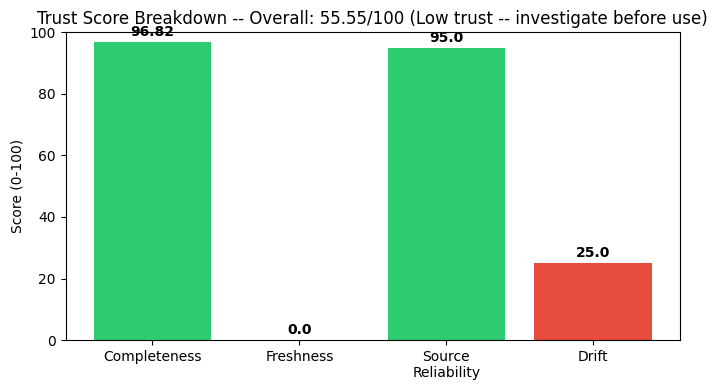

In [13]:
labels = ["Completeness", "Freshness", "Source\nReliability", "Drift"]
scores = [completeness_result.score, freshness_result.score, source_result.score, drift_result.score]
colors = ["#2ecc71" if s >= 70 else "#f1c40f" if s >= 40 else "#e74c3c" for s in scores]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, scores, color=colors)
ax.set_ylim(0, 100)
ax.set_ylabel("Score (0-100)")
ax.set_title(f"Trust Score Breakdown -- Overall: {overall_score}/100 ({label})")
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, s + 2, f"{s}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 12. JSON Export (for piping into other tools / dashboards)

In [14]:
result_dict = {
    "dataset_name": "current_sales (production_database)",
    "scored_at": datetime.utcnow().isoformat(),
    "overall_score": overall_score,
    "label": label,
    "weights": DEFAULT_WEIGHTS,
    "completeness": completeness_result.__dict__,
    "freshness": freshness_result.__dict__,
    "source_reliability": source_result.__dict__,
    "drift": {
        "score": drift_result.score,
        "columns_checked": drift_result.columns_checked,
        "columns_drifted": drift_result.columns_drifted,
        "details": [d.__dict__ for d in drift_result.details],
    },
}

print(json.dumps(result_dict, indent=2, default=str))


{
  "dataset_name": "current_sales (production_database)",
  "scored_at": "2026-09-19T09:07:58.183275",
  "overall_score": 55.55,
  "label": "Low trust -- investigate before use",
  "weights": {
    "completeness": 0.3,
    "freshness": 0.2,
    "source_reliability": 0.2,
    "drift": 0.3
  },
  "completeness": {
    "score": 96.82,
    "overall_fill_rate": 0.9682,
    "per_column_fill_rate": {
      "order_id": 1.0,
      "customer_age": 0.8756,
      "order_value": 0.9811,
      "items_in_order": 1.0,
      "region": 0.9528,
      "last_updated": 1.0
    },
    "worst_columns": [
      [
        "customer_age",
        0.8756
      ],
      [
        "region",
        0.9528
      ],
      [
        "order_value",
        0.9811
      ],
      [
        "order_id",
        1.0
      ],
      [
        "items_in_order",
        1.0
      ]
    ]
  },
  "freshness": {
    "score": 0.0,
    "age_days": 385.38,
    "newest_timestamp": "2025-08-30 00:00:00",
    "timestamp_column": "last_

/tmp/ipykernel_94/290452541.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "scored_at": datetime.utcnow().isoformat(),


## 13. Conclusions

- The trust score computed above correctly flagged the current dataset as lower-trust,
  driven mainly by staleness and statistical drift in `customer_age` and `order_value` --
  exactly the issues that were deliberately injected into the synthetic data.
- Completeness and source reliability were both strong, which is why the overall
  score isn't lower still -- the weighted design means one weak check doesn't
  automatically tank the whole score, but it is visible in the breakdown.
- **Business takeaway:** an analyst who ran this check before building a model on
  `current_sales.csv` would have caught the drift and staleness issues in seconds,
  instead of discovering them later as unexplained model performance degradation.

## 14. Possible Extensions

- Categorical drift detection (chi-squared test) alongside the numeric KS test
- Scheduled scoring with automated alerts when a score drops below a threshold
- A small score-history log to track a dataset's trust score over time
- An optional AI-generated narrative summary layered on top of the deterministic
  score (e.g. via an LLM), useful for non-technical stakeholders -- the scoring
  logic itself stays fully deterministic and auditable either way

## Tech Stack

Python, pandas, NumPy, SciPy (Kolmogorov-Smirnov test), Matplotlib. Scaffolded
and iterated on with **IBM Bob** in VS Code as part of the AI-assisted
development workflow for this internship.
